# Running an aquaplanet test case

First we set up the mpi environment:

In [1]:
from pyrte_rrtmgp.rrtmgp_data_files import download_rrtmgp_data

download_rrtmgp_data()

'/root/.cache/pyrte_rrtmgp/rrtmgp-data-1.9'

In [2]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.09engine/s]
%autopx enabled


[4:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[7], line 1
----> 1 get_ipython().run_cell_magic('time', '', 'try:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File /usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2572, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2570 with self.builtin_trap:
   2571     args = (magic_arg_s, cell)
-> 2572     result = fn(*args, **kwargs)
   2574 # The code below prevents the output from being displayed
   2575 # when using magics with decorator @output_can_be_silenced
   2576 # when the last Python token in the expression is a ';'.
   2577 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /usr/local/lib/python3.12/site-packages/IPython/core/magics/execution.py:1447, in ExecutionMagics.time(self, line, cell, local_ns)
   1445 if interrupt_occured:
   1446  

[3:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[7], line 1
----> 1 get_ipython().run_cell_magic('time', '', 'try:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File /usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2572, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2570 with self.builtin_trap:
   2571     args = (magic_arg_s, cell)
-> 2572     result = fn(*args, **kwargs)
   2574 # The code below prevents the output from being displayed
   2575 # when using magics with decorator @output_can_be_silenced
   2576 # when the last Python token in the expression is a ';'.
   2577 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /usr/local/lib/python3.12/site-packages/IPython/core/magics/execution.py:1447, in ExecutionMagics.time(self, line, cell, local_ns)
   1445 if interrupt_occured:
   1446  

In [3]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


In [4]:
%%capture

from pace import Driver, DriverConfig
import yaml
import os

os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

config_file = "aquaplanet_c16.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

%px: 100%|███████████████████████████████████████████████████████████████████| 6/6 [03:13<00:00, 32.18s/tasks]


In [5]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)

[stdout:0] (27, 27)


We can inspect the initial model state:

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

In [7]:
if mpi_rank == 0:
    print(temperature.shape)
    print(grid_lon.data.shape)
    print(grid_lat.shape)
    print(driver.state.dycore_state.pt.shape)
#     print(driver.state.dycore_state.pt.field[:,:,-2])

[stdout:0] (6, 20, 20, 79)
(6, 21, 21)
(6, 21, 21)
(27, 27, 80)


[output:0]

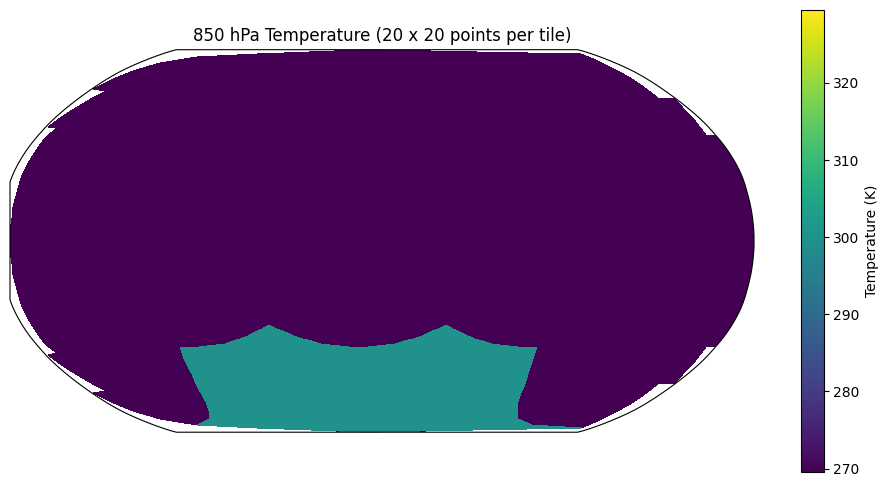

In [8]:
if mpi_rank == 0:
    nx=12
    u_mean = 0.5 * (u_wind.field[:,:,:-1, :] + u_wind.field[:,:, 1:, :])
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.field[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

And then we can run the model:

In [9]:
%%time
try:
    driver.step_all()
finally:
    driver.cleanup()

%px:   0%|                                                                           | 0/6 [00:01<?, ?tasks/s]

[stdout:5] CPU times: user 2.52 s, sys: 415 ms, total: 2.93 s
Wall time: 3 s


%px:   0%|                                                                           | 0/6 [00:01<?, ?tasks/s]

[stdout:4] CPU times: user 2.55 s, sys: 393 ms, total: 2.94 s
Wall time: 2.99 s


[stdout:1] CPU times: user 2.51 s, sys: 423 ms, total: 2.93 s
Wall time: 2.99 s


...

[stdout:0] CPU times: user 2.58 s, sys: 419 ms, total: 3 s
Wall time: 3 s


%px:  17%|███████████▏                                                       | 1/6 [00:01<00:00,  9.94tasks/s]

[stdout:3] CPU times: user 2.5 s, sys: 440 ms, total: 2.94 s
Wall time: 2.99 s


%px: 100%|███████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  3.13tasks/s]


AlreadyDisplayedError: 6 errors

Now let's investigate the model state

In [10]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)

In [11]:
if mpi_rank == 0:
    print(temperature.data[:,:,:,-2].shape)
    print(grid_lat.data.shape)
    print(grid_lon.data.shape)
    print(np.all(np.isnan(u_wind.data)))

[stdout:0] (6, 20, 20)
(6, 21, 21)
(6, 21, 21)
False


[output:0]

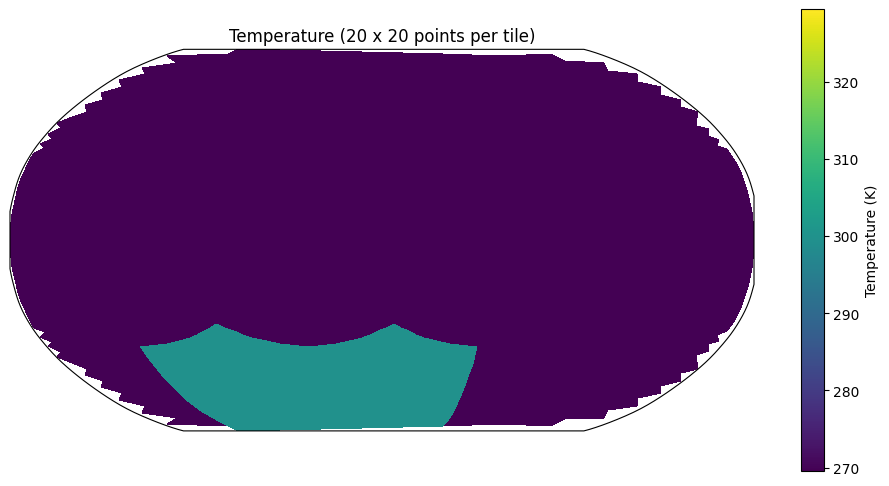

[output:0]

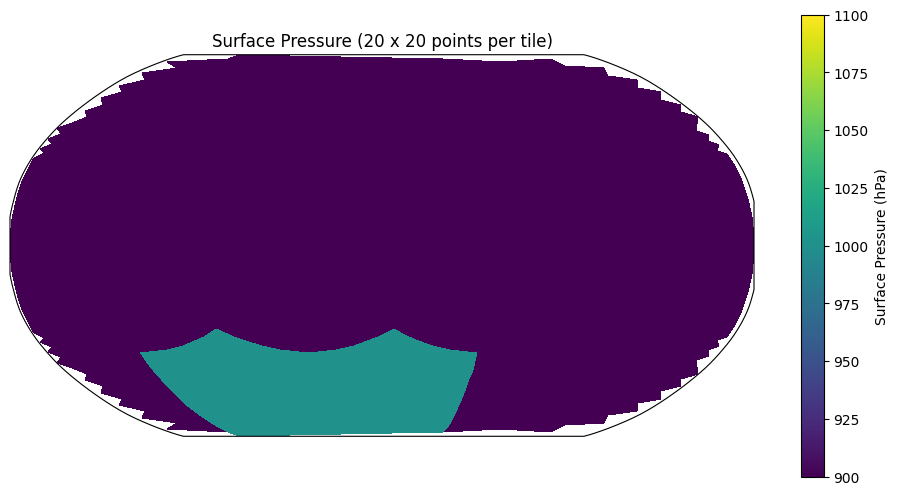

[output:0]

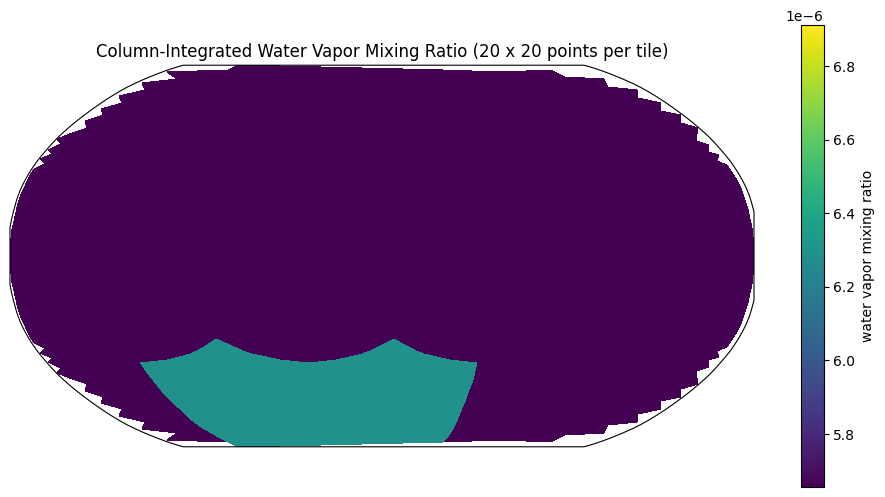

[output:0]

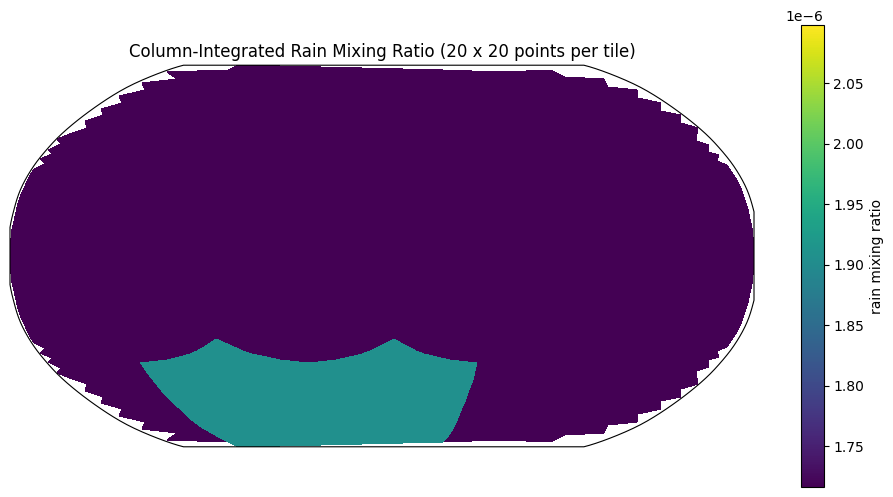

[output:0]

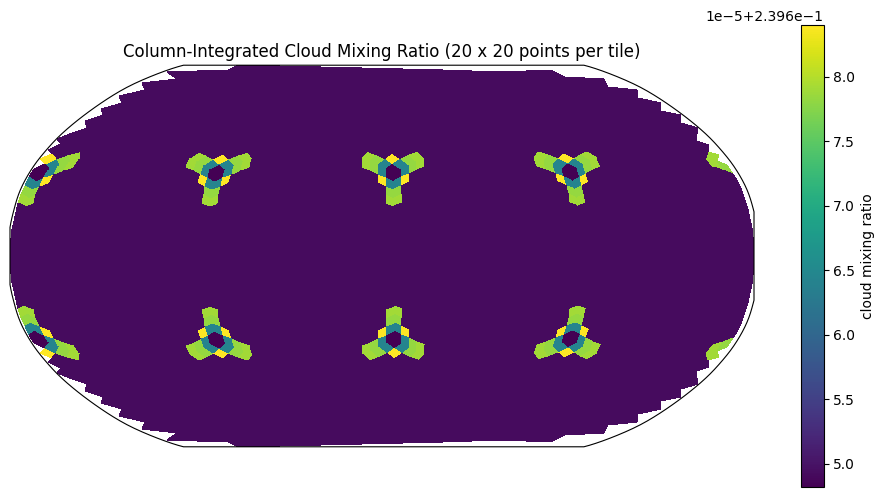

In [12]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")